### Product Performance Rankings (Dimensionality Reduction, Outlier Detection, Aggregation)

This project processes complex data through a series of steps designed for exploratory data analysis, dimensionality reduction, outlier detection, and product ranking.

### Import Libraries

This cell loads the essential libraries for data manipulation and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

### Mount Google Drive

This cell mounts your Google Drive to the Colab environment, allowing access to files stored in your Drive.

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### Data Loading

This cell specifies the path to the CSV data file on Google Drive and loads it into a pandas DataFrame named `nir`.

In [3]:
nirdata = '/content/gdrive/MyDrive/rawdata.csv'
nir = pd.read_csv(nirdata)
nir

,Scan GUID,Model GUID,UtcTimeStamp,JSON File Name,Product ID,908.1,914.294,920.489,926.683,932.877,...,1620.451,1626.645,1632.84,1639.034,1645.228,1651.423,1657.617,1663.811,1670.006,1676.2
0,1F93B0BF-826E-404F-A3E6-529CD03EB6D3,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T09:39:36-05:00,2025-12-22T14_39_36.583Z.cdm.json,Experimental_5,0.530494,0.508254,0.487396,0.468565,0.453412,...,0.654809,0.648295,0.642536,0.637978,0.634133,0.631134,0.629492,0.628374,0.627930,0.627512
1,0734105A-0A1C-4BAF-B40A-575D39EC1755,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T09:39:42-05:00,2025-12-22T14_39_42.289Z.cdm.json,Experimental_5,0.490963,0.470493,0.449835,0.430918,0.416420,...,0.623440,0.617856,0.613083,0.609478,0.606553,0.604735,0.604251,0.604275,0.604904,0.605249
2,8800978A-2473-475F-87C7-28391DDE0A18,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T09:39:47-05:00,2025-12-22T14_39_47.240Z.cdm.json,Experimental_5,0.454145,0.429982,0.406194,0.383782,0.366497,...,0.615328,0.609335,0.604231,0.600257,0.597183,0.595119,0.594513,0.594471,0.594974,0.595136
3,2837BA1A-7AAB-4BCC-B0F0-1A6B39382D45,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T09:39:52-05:00,2025-12-22T14_39_52.247Z.cdm.json,Experimental_5,0.441140,0.414335,0.388309,0.363889,0.344592,...,0.631349,0.625418,0.620295,0.616381,0.613282,0.611267,0.610658,0.610507,0.611021,0.611323
4,51C6FADF-C9C7-487E-818C-85767B00003A,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T09:39:56-05:00,2025-12-22T14_39_56.837Z.cdm.json,Experimental_5,0.583318,0.562671,0.541686,0.522002,0.506597,...,0.716771,0.710458,0.704985,0.700857,0.697404,0.695155,0.694282,0.693925,0.694219,0.694273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429,4692D710-A73F-4D7C-BE80-77D9AD90FD37,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T11:03:13-05:00,2025-12-22T16_03_13.599Z.cdm.json,Experimental_1,0.580876,0.583358,0.586738,0.597488,0.605522,...,0.530829,0.526818,0.523203,0.520528,0.518147,0.516191,0.515393,0.515229,0.517008,0.519541
430,F0974D2A-6078-400D-B677-A4B2F81F673C,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T11:03:19-05:00,2025-12-22T16_03_19.809Z.cdm.json,Experimental_1,0.574552,0.577877,0.583700,0.590291,0.597086,...,0.564728,0.559499,0.554985,0.551271,0.547987,0.545169,0.543169,0.541409,0.540280,0.538850
431,A2DEDBE1-82C0-4CE5-9165-343A3A050761,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T11:03:28-05:00,2025-12-22T16_03_28.298Z.cdm.json,Experimental_1,0.634557,0.645331,0.658431,0.681222,0.698934,...,0.524377,0.520958,0.517757,0.515490,0.513485,0.511908,0.511394,0.511421,0.513453,0.516112
432,7135AFF4-A401-43D5-B8AA-587EE57434E5,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T11:03:35-05:00,2025-12-22T16_03_35.537Z.cdm.json,Experimental_1,0.520236,0.531103,0.543468,0.558062,0.573060,...,0.466319,0.462581,0.459360,0.456810,0.454614,0.452706,0.451433,0.450362,0.449755,0.448859


### Create DataFrame Copy

This cell creates a copy of the original `nir` DataFrame, naming it `df_nir` to ensure that any modifications made during the analysis do not affect the raw data.

In [4]:
df_nir = pd.DataFrame(nir)

### Initial Data Quality Overview

This cell provides an initial overview of the DataFrame's structure and content, including its shape, data types, and descriptive statistics, to identify potential issues like missing values or incorrect types.

In [5]:
print('df_nir info')
display(df_nir.shape)
display(df_nir.info())
display(df_nir.describe())

df_nir info


(434, 130)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434 entries, 0 to 433
Columns: 130 entries, Scan GUID to 1676.2
dtypes: float64(125), object(5)
memory usage: 440.9+ KB


None

,908.1,914.294,920.489,926.683,932.877,939.072,945.266,951.46,957.655,963.849,...,1620.451,1626.645,1632.84,1639.034,1645.228,1651.423,1657.617,1663.811,1670.006,1676.2
count,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,...,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000
mean,0.538852,0.528130,0.518782,0.512884,0.508734,0.504927,0.503467,0.504996,0.506604,0.505559,...,0.594861,0.590086,0.586004,0.582937,0.580373,0.578432,0.577523,0.577093,0.577475,0.577851
std,0.100952,0.105136,0.111863,0.122297,0.132647,0.138743,0.142697,0.145088,0.144691,0.143647,...,0.116078,0.115626,0.115387,0.115546,0.115684,0.115826,0.116001,0.116173,0.116037,0.115930
min,0.186234,0.151158,0.152290,0.231801,0.259429,0.247593,0.240482,0.239286,0.206040,0.131927,...,0.423099,0.420717,0.418524,0.417225,0.416257,0.415631,0.416200,0.417776,0.418035,0.417660
25%,0.479880,0.463806,0.448103,0.434724,0.421198,0.413603,0.408899,0.409233,0.410960,0.409544,...,0.538612,0.534415,0.530731,0.528022,0.525831,0.524228,0.523778,0.523819,0.524449,0.525952
50%,0.526875,0.518116,0.506352,0.497494,0.492181,0.487810,0.484967,0.485746,0.487391,0.486578,...,0.586669,0.581306,0.577065,0.574154,0.571651,0.569379,0.567988,0.567542,0.567826,0.567675
75%,0.578839,0.572386,0.571250,0.572800,0.572288,0.572881,0.576775,0.582327,0.586013,0.585090,...,0.632244,0.626740,0.622590,0.619004,0.615989,0.613078,0.611665,0.611101,0.611234,0.612845
max,1.420775,1.370299,1.366344,1.478386,1.611296,1.618459,1.579116,1.558354,1.486556,1.373430,...,2.095425,2.087535,2.084928,2.092785,2.099680,2.106016,2.112538,2.119709,2.119450,2.120278


### Display Column Titles

This cell prints a list of all column titles in the `df_nir` DataFrame, which is useful for quickly understanding the available features and for subsequent data selection.

In [6]:
print('df_nir Column Titles')
print(df_nir.columns.tolist())

df_nir Column Titles
['Scan GUID', 'Model GUID', 'UtcTimeStamp', 'JSON File Name', 'Product ID', '908.1', '914.294', '920.489', '926.683', '932.877', '939.072', '945.266', '951.46', '957.655', '963.849', '970.044', '976.238', '982.432', '988.627', '994.821', '1001.015', '1007.21', '1013.404', '1019.598', '1025.793', '1031.987', '1038.181', '1044.376', '1050.57', '1056.765', '1062.959', '1069.153', '1075.348', '1081.542', '1087.736', '1093.931', '1100.125', '1106.319', '1112.514', '1118.708', '1124.902', '1131.097', '1137.291', '1143.485', '1149.68', '1155.874', '1162.069', '1168.263', '1174.457', '1180.652', '1186.846', '1193.04', '1199.235', '1205.429', '1211.623', '1217.818', '1224.012', '1230.206', '1236.401', '1242.595', '1248.79', '1254.984', '1261.178', '1267.373', '1273.567', '1279.761', '1285.956', '1292.15', '1298.344', '1304.539', '1310.733', '1316.927', '1323.122', '1329.316', '1335.51', '1341.705', '1347.899', '1354.094', '1360.288', '1366.482', '1372.677', '1378.871', '138

### Spectral Data Preprocessing and Initial PCA

This cell identifies spectral columns by checking if they are numeric and not part of the non-spectral columns based on the output of df_nir.columns.tolist().

In [7]:
non_spectral_cols = ['Scan GUID', 'Model GUID', 'UtcTimeStamp', 'JSON File Name', 'Product ID']
spectral_cols = [col for col in df_nir.columns if col not in non_spectral_cols]

#Ensure all spectral_cols can be converted to float for consistency (as per earlier cells)
spectral_cols = [col for col in spectral_cols if str(col).replace('.', '', 1).isdigit()]

X_spectral = df_nir[spectral_cols]

### Standardize Spectral Data

This cell standardizes the spectral data using `StandardScaler`, ensuring that each spectral band contributes equally to the PCA.

In [8]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_spectral),
                        columns=X_spectral.columns,
                        index=X_spectral.index)

print("Shape of X_spectral:", X_spectral.shape)
print("Shape of X_scaled:", X_scaled.shape)
display(X_scaled.head())

Shape of X_spectral: (434, 125)
Shape of X_scaled: (434, 125)


,908.1,914.294,920.489,926.683,932.877,939.072,945.266,951.46,957.655,963.849,...,1620.451,1626.645,1632.84,1639.034,1645.228,1651.423,1657.617,1663.811,1670.006,1676.2
0,-0.082893,-0.189274,-0.280896,-0.362811,-0.417547,-0.451808,-0.476461,-0.487615,-0.487649,-0.491605,...,0.517041,0.504006,0.490507,0.476903,0.465251,0.455537,0.448527,0.441936,0.435318,0.428868
1,-0.474923,-0.548844,-0.617058,-0.671001,-0.696743,-0.715600,-0.731833,-0.736125,-0.741276,-0.748225,...,0.246489,0.240448,0.234952,0.229964,0.226575,0.227357,0.230682,0.234249,0.236653,0.236609
2,-0.840053,-0.934615,-1.007642,-1.056862,-1.073539,-1.088415,-1.105286,-1.107790,-1.111012,-1.112776,...,0.176525,0.166663,0.158149,0.150070,0.145483,0.144240,0.146638,0.149765,0.150979,0.149272
3,-0.969020,-1.083611,-1.167704,-1.219714,-1.238869,-1.254440,-1.261099,-1.256077,-1.252819,-1.255996,...,0.314704,0.305919,0.297528,0.289779,0.284801,0.283817,0.285979,0.287963,0.289424,0.289056
4,0.440973,0.328913,0.204989,0.074643,-0.016136,-0.073766,-0.109602,-0.121547,-0.127771,-0.129403,...,1.051454,1.042248,1.032347,1.021723,1.012813,1.008910,1.007693,1.006842,1.007253,1.005400


### Display `X_spectral` Column Titles

This cell prints the column titles of the `X_spectral` DataFrame to confirm the identified spectral bands before standardization.

In [9]:
print('X_spectral Column Titles')
print(X_spectral.columns.tolist())

X_spectral Column Titles
['908.1', '914.294', '920.489', '926.683', '932.877', '939.072', '945.266', '951.46', '957.655', '963.849', '970.044', '976.238', '982.432', '988.627', '994.821', '1001.015', '1007.21', '1013.404', '1019.598', '1025.793', '1031.987', '1038.181', '1044.376', '1050.57', '1056.765', '1062.959', '1069.153', '1075.348', '1081.542', '1087.736', '1093.931', '1100.125', '1106.319', '1112.514', '1118.708', '1124.902', '1131.097', '1137.291', '1143.485', '1149.68', '1155.874', '1162.069', '1168.263', '1174.457', '1180.652', '1186.846', '1193.04', '1199.235', '1205.429', '1211.623', '1217.818', '1224.012', '1230.206', '1236.401', '1242.595', '1248.79', '1254.984', '1261.178', '1267.373', '1273.567', '1279.761', '1285.956', '1292.15', '1298.344', '1304.539', '1310.733', '1316.927', '1323.122', '1329.316', '1335.51', '1341.705', '1347.899', '1354.094', '1360.288', '1366.482', '1372.677', '1378.871', '1385.065', '1391.26', '1397.454', '1403.648', '1409.843', '1416.037', '142

### Display `X_scaled` Column Titles

This cell prints the column titles of the standardized `X_scaled` DataFrame.

In [10]:
print('X_scaled Column Titles')
print(X_scaled.columns.tolist())

X_scaled Column Titles
['908.1', '914.294', '920.489', '926.683', '932.877', '939.072', '945.266', '951.46', '957.655', '963.849', '970.044', '976.238', '982.432', '988.627', '994.821', '1001.015', '1007.21', '1013.404', '1019.598', '1025.793', '1031.987', '1038.181', '1044.376', '1050.57', '1056.765', '1062.959', '1069.153', '1075.348', '1081.542', '1087.736', '1093.931', '1100.125', '1106.319', '1112.514', '1118.708', '1124.902', '1131.097', '1137.291', '1143.485', '1149.68', '1155.874', '1162.069', '1168.263', '1174.457', '1180.652', '1186.846', '1193.04', '1199.235', '1205.429', '1211.623', '1217.818', '1224.012', '1230.206', '1236.401', '1242.595', '1248.79', '1254.984', '1261.178', '1267.373', '1273.567', '1279.761', '1285.956', '1292.15', '1298.344', '1304.539', '1310.733', '1316.927', '1323.122', '1329.316', '1335.51', '1341.705', '1347.899', '1354.094', '1360.288', '1366.482', '1372.677', '1378.871', '1385.065', '1391.26', '1397.454', '1403.648', '1409.843', '1416.037', '1422.

### View Original Spectral Data (`X_spectral`)

This cell displays the first few rows, information, and descriptive statistics of the original `X_spectral` DataFrame.

In [11]:
display(X_spectral)
display(X_spectral.info())
display(X_spectral.describe())

,908.1,914.294,920.489,926.683,932.877,939.072,945.266,951.46,957.655,963.849,...,1620.451,1626.645,1632.84,1639.034,1645.228,1651.423,1657.617,1663.811,1670.006,1676.2
0,0.530494,0.508254,0.487396,0.468565,0.453412,0.442314,0.435556,0.434331,0.436127,0.435023,...,0.654809,0.648295,0.642536,0.637978,0.634133,0.631134,0.629492,0.628374,0.627930,0.627512
1,0.490963,0.470493,0.449835,0.430918,0.416420,0.405757,0.399157,0.398316,0.399472,0.398203,...,0.623440,0.617856,0.613083,0.609478,0.606553,0.604735,0.604251,0.604275,0.604904,0.605249
2,0.454145,0.429982,0.406194,0.383782,0.366497,0.354091,0.345928,0.344454,0.346036,0.345896,...,0.615328,0.609335,0.604231,0.600257,0.597183,0.595119,0.594513,0.594471,0.594974,0.595136
3,0.441140,0.414335,0.388309,0.363889,0.344592,0.331083,0.323719,0.322965,0.325541,0.325347,...,0.631349,0.625418,0.620295,0.616381,0.613282,0.611267,0.610658,0.610507,0.611021,0.611323
4,0.583318,0.562671,0.541686,0.522002,0.506597,0.494704,0.487845,0.487382,0.488138,0.486992,...,0.716771,0.710458,0.704985,0.700857,0.697404,0.695155,0.694282,0.693925,0.694219,0.694273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429,0.580876,0.583358,0.586738,0.597488,0.605522,0.610543,0.621217,0.627399,0.632298,0.631851,...,0.530829,0.526818,0.523203,0.520528,0.518147,0.516191,0.515393,0.515229,0.517008,0.519541
430,0.574552,0.577877,0.583700,0.590291,0.597086,0.604492,0.611166,0.617570,0.621823,0.625175,...,0.564728,0.559499,0.554985,0.551271,0.547987,0.545169,0.543169,0.541409,0.540280,0.538850
431,0.634557,0.645331,0.658431,0.681222,0.698934,0.711501,0.729312,0.738390,0.744639,0.744345,...,0.524377,0.520958,0.517757,0.515490,0.513485,0.511908,0.511394,0.511421,0.513453,0.516112
432,0.520236,0.531103,0.543468,0.558062,0.573060,0.585948,0.596937,0.605671,0.610545,0.614939,...,0.466319,0.462581,0.459360,0.456810,0.454614,0.452706,0.451433,0.450362,0.449755,0.448859


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434 entries, 0 to 433
Columns: 125 entries, 908.1 to 1676.2
dtypes: float64(125)
memory usage: 424.0 KB


None

,908.1,914.294,920.489,926.683,932.877,939.072,945.266,951.46,957.655,963.849,...,1620.451,1626.645,1632.84,1639.034,1645.228,1651.423,1657.617,1663.811,1670.006,1676.2
count,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,...,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000,434.000000
mean,0.538852,0.528130,0.518782,0.512884,0.508734,0.504927,0.503467,0.504996,0.506604,0.505559,...,0.594861,0.590086,0.586004,0.582937,0.580373,0.578432,0.577523,0.577093,0.577475,0.577851
std,0.100952,0.105136,0.111863,0.122297,0.132647,0.138743,0.142697,0.145088,0.144691,0.143647,...,0.116078,0.115626,0.115387,0.115546,0.115684,0.115826,0.116001,0.116173,0.116037,0.115930
min,0.186234,0.151158,0.152290,0.231801,0.259429,0.247593,0.240482,0.239286,0.206040,0.131927,...,0.423099,0.420717,0.418524,0.417225,0.416257,0.415631,0.416200,0.417776,0.418035,0.417660
25%,0.479880,0.463806,0.448103,0.434724,0.421198,0.413603,0.408899,0.409233,0.410960,0.409544,...,0.538612,0.534415,0.530731,0.528022,0.525831,0.524228,0.523778,0.523819,0.524449,0.525952
50%,0.526875,0.518116,0.506352,0.497494,0.492181,0.487810,0.484967,0.485746,0.487391,0.486578,...,0.586669,0.581306,0.577065,0.574154,0.571651,0.569379,0.567988,0.567542,0.567826,0.567675
75%,0.578839,0.572386,0.571250,0.572800,0.572288,0.572881,0.576775,0.582327,0.586013,0.585090,...,0.632244,0.626740,0.622590,0.619004,0.615989,0.613078,0.611665,0.611101,0.611234,0.612845
max,1.420775,1.370299,1.366344,1.478386,1.611296,1.618459,1.579116,1.558354,1.486556,1.373430,...,2.095425,2.087535,2.084928,2.092785,2.099680,2.106016,2.112538,2.119709,2.119450,2.120278


### View Standardized Spectral Data (`X_scaled`)

This cell displays the first few rows, information, and descriptive statistics of the standardized `X_scaled` DataFrame.

In [12]:
display(X_scaled)
display(X_scaled.info())
display(X_scaled.describe())

,908.1,914.294,920.489,926.683,932.877,939.072,945.266,951.46,957.655,963.849,...,1620.451,1626.645,1632.84,1639.034,1645.228,1651.423,1657.617,1663.811,1670.006,1676.2
0,-0.082893,-0.189274,-0.280896,-0.362811,-0.417547,-0.451808,-0.476461,-0.487615,-0.487649,-0.491605,...,0.517041,0.504006,0.490507,0.476903,0.465251,0.455537,0.448527,0.441936,0.435318,0.428868
1,-0.474923,-0.548844,-0.617058,-0.671001,-0.696743,-0.715600,-0.731833,-0.736125,-0.741276,-0.748225,...,0.246489,0.240448,0.234952,0.229964,0.226575,0.227357,0.230682,0.234249,0.236653,0.236609
2,-0.840053,-0.934615,-1.007642,-1.056862,-1.073539,-1.088415,-1.105286,-1.107790,-1.111012,-1.112776,...,0.176525,0.166663,0.158149,0.150070,0.145483,0.144240,0.146638,0.149765,0.150979,0.149272
3,-0.969020,-1.083611,-1.167704,-1.219714,-1.238869,-1.254440,-1.261099,-1.256077,-1.252819,-1.255996,...,0.314704,0.305919,0.297528,0.289779,0.284801,0.283817,0.285979,0.287963,0.289424,0.289056
4,0.440973,0.328913,0.204989,0.074643,-0.016136,-0.073766,-0.109602,-0.121547,-0.127771,-0.129403,...,1.051454,1.042248,1.032347,1.021723,1.012813,1.008910,1.007693,1.006842,1.007253,1.005400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429,0.416748,0.525902,0.608192,0.692586,0.730502,0.762115,0.826131,0.844620,0.869701,0.880195,...,-0.552265,-0.547810,-0.544895,-0.540749,-0.538512,-0.537988,-0.536208,-0.533129,-0.521706,-0.503554
430,0.354033,0.473713,0.581002,0.633674,0.666833,0.718450,0.755618,0.776791,0.797223,0.833667,...,-0.259890,-0.264845,-0.269134,-0.274375,-0.280271,-0.287508,-0.296489,-0.307513,-0.320915,-0.336804
431,0.949112,1.116035,1.249834,1.378058,1.435539,1.490618,1.584520,1.610488,1.647015,1.664227,...,-0.607914,-0.598552,-0.592141,-0.584396,-0.578861,-0.575006,-0.570727,-0.565946,-0.552376,-0.533168
432,-0.184619,0.028304,0.220932,0.369832,0.485496,0.584643,0.655785,0.694688,0.719191,0.762324,...,-1.108651,-1.104015,-1.098828,-1.092834,-1.088343,-1.086720,-1.088219,-1.092140,-1.101958,-1.113954


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434 entries, 0 to 433
Columns: 125 entries, 908.1 to 1676.2
dtypes: float64(125)
memory usage: 424.0 KB


None

,908.1,914.294,920.489,926.683,932.877,939.072,945.266,951.46,957.655,963.849,...,1620.451,1626.645,1632.84,1639.034,1645.228,1651.423,1657.617,1663.811,1670.006,1676.2
count,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02,...,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02,4.340000e+02
mean,-2.865092e-16,4.870656e-16,-3.192531e-16,-9.823171e-17,-1.350686e-16,6.098552e-16,-3.765549e-16,-4.011128e-16,-1.759985e-16,1.309756e-16,...,2.455793e-17,2.619512e-16,5.075305e-16,7.367379e-17,-6.958080e-16,-4.011128e-16,1.391616e-16,-3.438110e-16,-9.250153e-16,2.619512e-16
std,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00,...,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00,1.001154e+00
min,-3.496948e+00,-3.589703e+00,-3.280030e+00,-2.301017e+00,-1.881643e+00,-1.856900e+00,-1.845092e+00,-1.833486e+00,-2.079673e+00,-2.604043e+00,...,-1.481418e+00,-1.466491e+00,-1.453142e+00,-1.435820e+00,-1.420285e+00,-1.407181e+00,-1.392300e+00,-1.372956e+00,-1.375633e+00,-1.383385e+00
25%,-5.848326e-01,-6.125299e-01,-6.325619e-01,-6.398379e-01,-6.606877e-01,-6.589840e-01,-6.634813e-01,-6.607975e-01,-6.617885e-01,-6.691773e-01,...,-4.851379e-01,-4.820295e-01,-4.795762e-01,-4.758161e-01,-4.720107e-01,-4.685162e-01,-4.638469e-01,-4.590991e-01,-4.575049e-01,-4.481955e-01
50%,-1.187818e-01,-9.535862e-02,-1.112426e-01,-1.259859e-01,-1.249342e-01,-1.235124e-01,-1.297900e-01,-1.328340e-01,-1.329421e-01,-1.322905e-01,...,-7.065048e-02,-7.602704e-02,-7.755422e-02,-7.610096e-02,-7.548167e-02,-7.825187e-02,-8.229290e-02,-8.230609e-02,-8.325308e-02,-8.787683e-02
75%,3.965513e-01,4.214236e-01,4.695827e-01,4.904861e-01,4.796735e-01,4.903488e-01,5.143264e-01,5.336029e-01,5.494499e-01,5.542929e-01,...,3.224215e-01,3.173707e-01,3.174398e-01,3.125046e-01,3.082324e-01,2.994637e-01,2.946631e-01,2.930797e-01,2.912692e-01,3.021993e-01
max,8.746099e+00,8.019525e+00,7.585512e+00,7.903847e+00,8.321610e+00,8.035141e+00,7.546719e+00,7.268501e+00,6.780517e+00,6.048654e+00,...,1.294215e+01,1.296576e+01,1.300544e+01,1.308212e+01,1.314838e+01,1.320381e+01,1.324800e+01,1.329395e+01,1.330396e+01,1.332016e+01


### Unify Notebook Plot Style
The cell sets the plotting style for the notebook using seaborn, ensuring consistent aesthetic choices across all plots in the notebook.

In [13]:
sns.set_style('darkgrid', {'axes.facecolor': '#D3D3D3'})
print("Notebook plot style set with light grey background.")

Notebook plot style set with light grey background.


### Principal Component Analysis (PCA)

This cell applies Principal Component Analysis (PCA) to the standardized spectral data, aiming to reduce dimensionality while retaining most of the variance for further analysis.

In [14]:
pca = PCA(n_components=None) #Keep all components initially to calculate explained variance
pca.fit(X_scaled)

principal_components = pca.transform(X_scaled)
pc_cols = [f'PC{i+1}' for i in range(principal_components.shape[1])]
principal_components_df = pd.DataFrame(data=principal_components,
                                       columns=pc_cols,
                                       index=X_scaled.index)

explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio for first 5 principal components:")
for i, ratio in enumerate(explained_variance_ratio[:5]):
    print(f"PC{i+1}: {ratio:.4f}")

print("\nFirst 5 rows of principal_components_df:")
display(principal_components_df.head())

Explained variance ratio for first 5 principal components:
PC1: 0.7716
PC2: 0.2149
PC3: 0.0081
PC4: 0.0036
PC5: 0.0012

First 5 rows of principal_components_df:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC116,PC117,PC118,PC119,PC120,PC121,PC122,PC123,PC124,PC125
0,0.433013,6.268447,-1.435312,1.284176,-0.187137,0.119170,-0.003518,0.046705,-0.101767,-0.043946,...,-0.000046,0.000027,-0.000209,0.000090,-1.230441e-04,0.000087,-0.000137,-0.000102,-0.000048,-0.000003
1,-2.586342,5.062456,-0.357177,0.088710,-0.156479,-0.043635,-0.023246,-0.007282,0.007575,0.055552,...,-0.000061,0.000127,0.000055,0.000011,-1.744893e-07,-0.000065,-0.000219,0.000108,0.000044,-0.000062
2,-4.980070,6.560826,-0.425906,0.131701,-0.282256,-0.095281,-0.152404,0.021791,0.038272,0.030642,...,-0.000247,-0.000147,0.000025,0.000203,-8.670252e-05,0.000068,-0.000001,0.000289,-0.000069,0.000080
3,-4.641200,7.831002,-0.317693,0.071726,-0.564151,-0.174828,-0.169028,-0.001395,-0.000325,0.058952,...,-0.000123,-0.000153,0.000163,-0.000011,-4.391963e-05,-0.000001,-0.000323,-0.000044,0.000073,0.000016
4,5.114980,5.990914,-1.458490,0.132829,-0.034926,0.035186,-0.078518,0.024798,-0.053933,-0.016756,...,0.000009,-0.000108,0.000275,-0.000381,2.652929e-04,-0.000088,-0.000040,-0.000082,0.000079,-0.000012


### Scree Plot of Explained Variance

This cell generates a scree plot to visualize the cumulative explained variance by each principal component. This plot helps in determining the optimal number of principal components to retain for further analysis by identifying the 'elbow' point where the explained variance starts to level off.

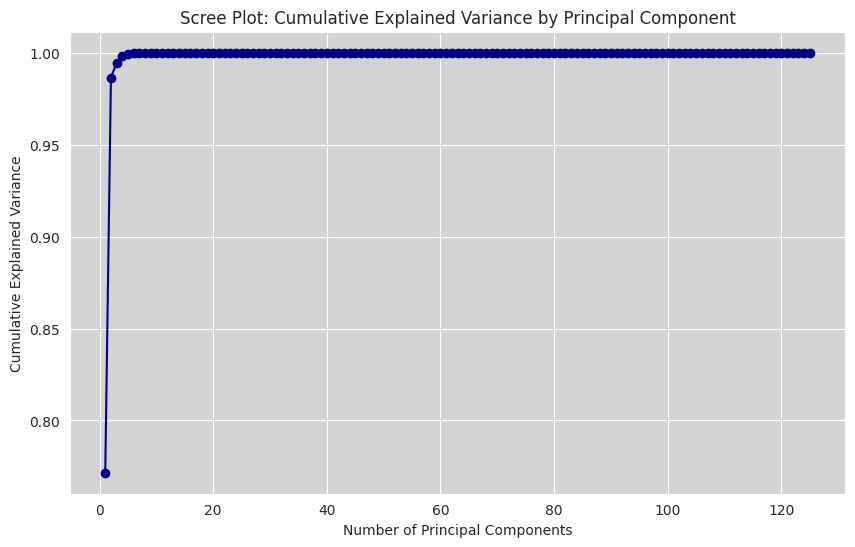

In [15]:
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-', color='darkblue')
plt.title('Scree Plot: Cumulative Explained Variance by Principal Component')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

### Focused Scree Plot

This cell generates a focused scree plot, focusing on the first 20 principal components. This helps in more closely examining the 'elbow' point within the initial components, which can guide decisions on the optimal number of components to retain.

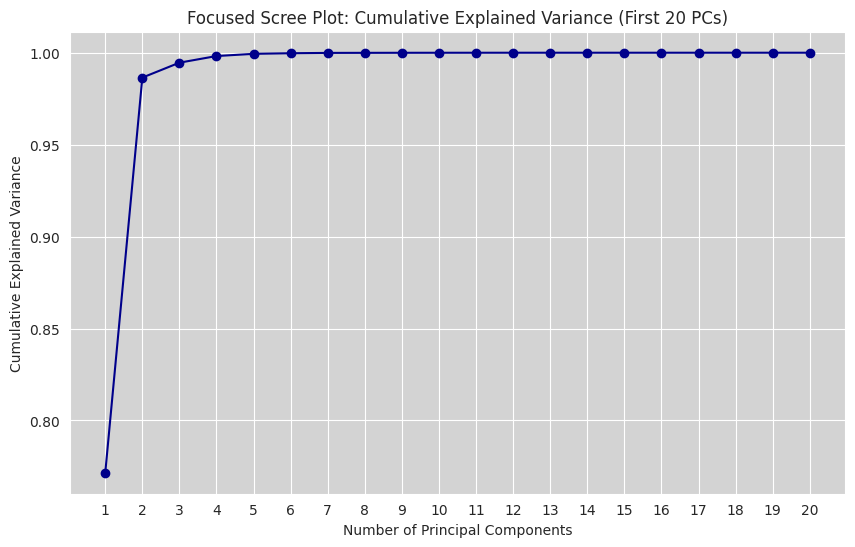

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), cumulative_explained_variance[:20], marker='o', linestyle='-', color='darkblue')
plt.title('Focused Scree Plot: Cumulative Explained Variance (First 20 PCs)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

### Visualizing Data Structure and Outliers with a PCA Scatter Plot

This cell simplifies highly-dimensional data into an interpretable visualization, enabling the quick identification of underlying patterns, clusters, outliers, and explained variance.

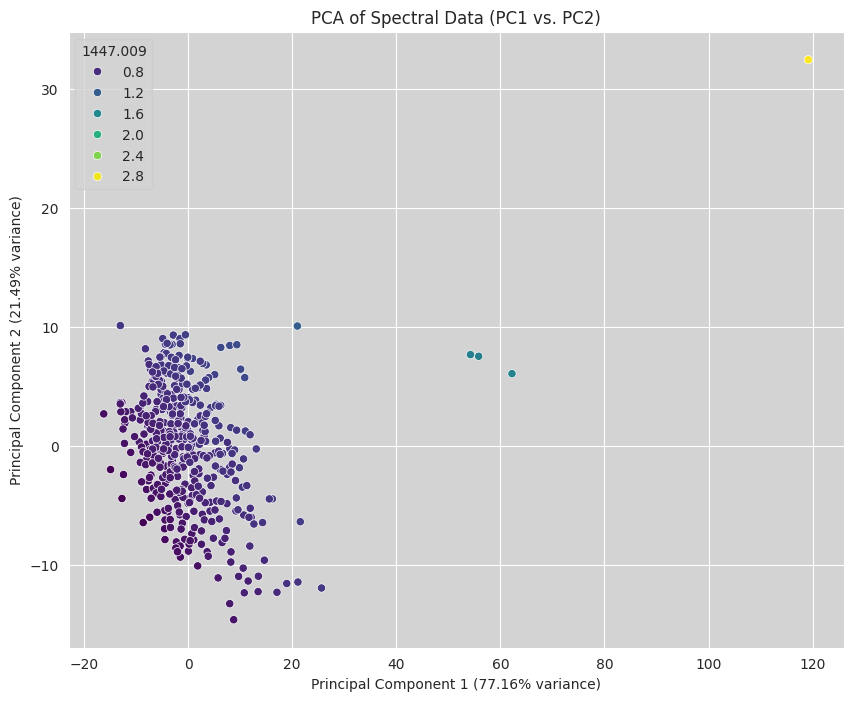

In [17]:
principal_components_df['1447.009'] = df_nir['1447.009']

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=principal_components_df, palette='viridis', hue='1447.009')
plt.title('PCA of Spectral Data (PC1 vs. PC2)')
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}% variance)')
plt.grid(True)
plt.show()

### Outlier Detection

This cell applies the Isolation Forest algorithm to PC1 and PC2 to identify and classify outliers in the spectral data and visualizes these outliers on the PCA scatter plot. The contamination parameter is currently set to 0.015, indicating that 1.5% of the data is expected to be outliers.

*   Best Practice: Set the value based on your domain knowledge of how rare anomalies are in your data.
*   Low Contamination (0.01 - 0.05): Ideal for fraud detection or, in general, when anomalies are extremely rare.
*   Moderate Contamination (0.05 - 0.10): Good starting point for general-purpose outlier detection.
*   High Contamination (> 0.10): Used when the data is noisy or the "normal" behavior is highly variable.
*   Low vs. High: A low contamination rate (e.g., 0.01) leads to high precision but low recall (misses anomalies).
*   A high rate (e.g., 0.2) leads to high recall but low precision (flags normal data as outliers).









Identified outliers based on PC1 and PC2 scores:


,PC1,PC2
12,21.102995,-11.467298
282,25.633492,-11.969082
330,119.168126,32.485284
344,20.996840,10.075458
347,55.828323,7.530772
348,62.229842,6.068331
360,54.255937,7.670129


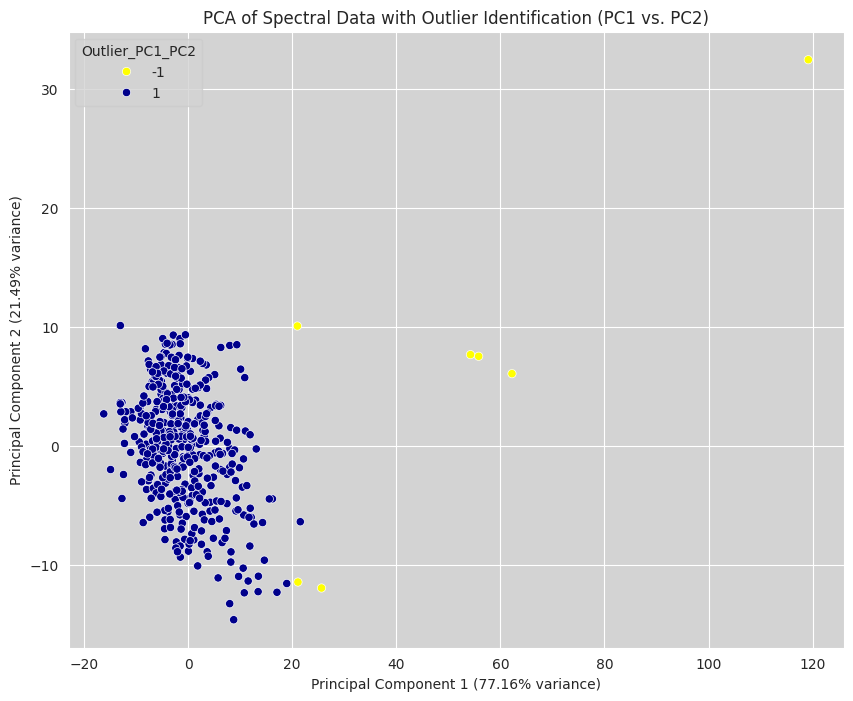

In [18]:
pc_data_for_outliers = principal_components_df[['PC1', 'PC2']]

isolation_forest = IsolationForest(contamination=.015, random_state=42)
isolation_forest.fit(pc_data_for_outliers)

outlier_predictions = isolation_forest.predict(pc_data_for_outliers)

principal_components_df['Outlier_PC1_PC2'] = outlier_predictions

pca_outliers = principal_components_df[principal_components_df['Outlier_PC1_PC2'] == -1]

print("Identified outliers based on PC1 and PC2 scores:")
display(pca_outliers[['PC1', 'PC2']])

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=principal_components_df, hue='Outlier_PC1_PC2', palette={1: 'darkblue', -1: 'yellow'})
plt.title('PCA of Spectral Data with Outlier Identification (PC1 vs. PC2)')
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}% variance)')
plt.grid(True)
plt.show()

### Remove PCA Outliers

This cell removes the identified PCA outliers from the original `df_nir` DataFrame, creating a new `df_no_pca_outliers` DataFrame for further analysis with a cleaner dataset.

In [19]:
#Identify the indices of the outliers based on PC1 and PC2
outlier_indices_pca = principal_components_df[principal_components_df['Outlier_PC1_PC2'] == -1].index

#Create a new DataFrame `df_no_pca_outliers` by dropping these outliers directly from `df_nir`
df_no_pca_outliers = df_nir.drop(index=outlier_indices_pca)

print(f"Original df_nir shape: {df_nir.shape}")
print(f"DataFrame after removing PCA outliers (df_no_pca_outliers) shape: {df_no_pca_outliers.shape}")

print("First 5 rows of df_no_pca_outliers:")
display(df_no_pca_outliers.head())

Original df_nir shape: (434, 130)
DataFrame after removing PCA outliers (df_no_pca_outliers) shape: (427, 130)
First 5 rows of df_no_pca_outliers:


,Scan GUID,Model GUID,UtcTimeStamp,JSON File Name,Product ID,908.1,914.294,920.489,926.683,932.877,...,1620.451,1626.645,1632.84,1639.034,1645.228,1651.423,1657.617,1663.811,1670.006,1676.2
0,1F93B0BF-826E-404F-A3E6-529CD03EB6D3,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T09:39:36-05:00,2025-12-22T14_39_36.583Z.cdm.json,Experimental_5,0.530494,0.508254,0.487396,0.468565,0.453412,...,0.654809,0.648295,0.642536,0.637978,0.634133,0.631134,0.629492,0.628374,0.627930,0.627512
1,0734105A-0A1C-4BAF-B40A-575D39EC1755,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T09:39:42-05:00,2025-12-22T14_39_42.289Z.cdm.json,Experimental_5,0.490963,0.470493,0.449835,0.430918,0.416420,...,0.623440,0.617856,0.613083,0.609478,0.606553,0.604735,0.604251,0.604275,0.604904,0.605249
2,8800978A-2473-475F-87C7-28391DDE0A18,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T09:39:47-05:00,2025-12-22T14_39_47.240Z.cdm.json,Experimental_5,0.454145,0.429982,0.406194,0.383782,0.366497,...,0.615328,0.609335,0.604231,0.600257,0.597183,0.595119,0.594513,0.594471,0.594974,0.595136
3,2837BA1A-7AAB-4BCC-B0F0-1A6B39382D45,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T09:39:52-05:00,2025-12-22T14_39_52.247Z.cdm.json,Experimental_5,0.441140,0.414335,0.388309,0.363889,0.344592,...,0.631349,0.625418,0.620295,0.616381,0.613282,0.611267,0.610658,0.610507,0.611021,0.611323
4,51C6FADF-C9C7-487E-818C-85767B00003A,065606C9-8C14-4AE4-BD0B-AF61759871B8,2025-12-22T09:39:56-05:00,2025-12-22T14_39_56.837Z.cdm.json,Experimental_5,0.583318,0.562671,0.541686,0.522002,0.506597,...,0.716771,0.710458,0.704985,0.700857,0.697404,0.695155,0.694282,0.693925,0.694219,0.694273


### Cleaned Data Quality Check

This cell performs a data quality check on the `df_no_pca_outliers` DataFrame, displaying its shape, information, and descriptive statistics after the outlier removal.

In [20]:
print('df_no_pca_outliers info')
display(df_no_pca_outliers.shape)
display(df_no_pca_outliers.info())
display(df_no_pca_outliers.describe())

df_no_pca_outliers info


(427, 130)

<class 'pandas.core.frame.DataFrame'>
Index: 427 entries, 0 to 433
Columns: 130 entries, Scan GUID to 1676.2
dtypes: float64(125), object(5)
memory usage: 437.0+ KB


None

,908.1,914.294,920.489,926.683,932.877,939.072,945.266,951.46,957.655,963.849,...,1620.451,1626.645,1632.84,1639.034,1645.228,1651.423,1657.617,1663.811,1670.006,1676.2
count,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,...,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000,427.000000
mean,0.531239,0.520646,0.511144,0.504569,0.499734,0.495791,0.494409,0.495954,0.497837,0.497267,...,0.585016,0.580254,0.576168,0.573066,0.570474,0.568512,0.567584,0.567140,0.567539,0.567932
std,0.075225,0.082321,0.090421,0.099401,0.107799,0.114782,0.120398,0.123534,0.124770,0.126082,...,0.065457,0.064844,0.064310,0.063882,0.063528,0.063270,0.063116,0.062991,0.062873,0.062799
min,0.186234,0.151158,0.152290,0.231801,0.259429,0.247593,0.240482,0.239286,0.206040,0.131927,...,0.423099,0.420717,0.418524,0.417225,0.416257,0.415631,0.416200,0.417776,0.418035,0.417660
25%,0.479771,0.463514,0.447332,0.433701,0.420372,0.412346,0.407701,0.406673,0.407674,0.406533,...,0.536939,0.532510,0.528762,0.525856,0.523636,0.522137,0.521589,0.521919,0.523958,0.525209
50%,0.525511,0.516145,0.503826,0.495458,0.489284,0.483423,0.479791,0.481752,0.483128,0.482894,...,0.584242,0.580445,0.576716,0.573229,0.570368,0.568461,0.567285,0.566818,0.567178,0.566771
75%,0.574303,0.570721,0.566535,0.566750,0.566696,0.568370,0.571071,0.575797,0.578245,0.579329,...,0.631315,0.625399,0.620150,0.616167,0.613107,0.611176,0.610623,0.609640,0.609634,0.610117
max,0.797492,0.797643,0.801861,0.812418,0.837631,0.865673,0.886747,0.906163,0.918001,0.923832,...,0.788042,0.781634,0.776096,0.771952,0.768286,0.765293,0.763551,0.762304,0.761832,0.761344


### Spectral Data Preparation and Standardization

This cell prepares and standardizes the spectral data from `df_no_pca_outliers` (the DataFrame after removing PCA outliers). This ensures the data is ready for a new PCA application.

In [21]:
spectral_cols_cleaned = [col for col in df_no_pca_outliers.columns if str(col).replace('.', '', 1).isdigit()]
X_spectral_cleaned = df_no_pca_outliers[spectral_cols_cleaned]

scaler_cleaned = StandardScaler()
X_scaled_cleaned = pd.DataFrame(scaler_cleaned.fit_transform(X_spectral_cleaned),
                                columns=X_spectral_cleaned.columns,
                                index=X_spectral_cleaned.index)

print("Shape of X_spectral_cleaned:", X_spectral_cleaned.shape)
print("Shape of X_scaled_cleaned:", X_scaled_cleaned.shape)
display(X_scaled_cleaned.head())

Shape of X_spectral_cleaned: (427, 125)
Shape of X_scaled_cleaned: (427, 125)


,908.1,914.294,920.489,926.683,932.877,939.072,945.266,951.46,957.655,963.849,...,1620.451,1626.645,1632.84,1639.034,1645.228,1651.423,1657.617,1663.811,1670.006,1676.2
0,-0.009912,-0.150710,-0.262946,-0.362633,-0.430212,-0.466447,-0.489396,-0.499425,-0.495168,-0.494261,...,1.067494,1.050532,1.033223,1.017319,1.003235,0.990929,0.982006,0.973251,0.961660,0.949854
1,-0.536031,-0.609945,-0.678830,-0.741819,-0.773769,-0.785312,-0.792071,-0.791301,-0.789296,-0.786638,...,0.587703,0.580562,0.574692,0.570661,0.568598,0.573198,0.581621,0.590211,0.595000,0.594929
2,-1.026049,-1.102642,-1.162043,-1.216570,-1.237424,-1.235961,-1.234699,-1.227823,-1.218072,-1.201986,...,0.463631,0.448991,0.436888,0.426149,0.420927,0.421034,0.427155,0.434395,0.436878,0.433698
3,-1.199127,-1.292937,-1.360065,-1.416937,-1.440866,-1.436649,-1.419373,-1.401986,-1.382523,-1.365162,...,0.708673,0.697309,0.686970,0.678852,0.674630,0.676560,0.683253,0.689275,0.692395,0.691750
4,0.693135,0.511105,0.338169,0.175595,0.063732,-0.009480,-0.054584,-0.069476,-0.077824,-0.081589,...,2.015211,2.010310,2.005422,2.002778,2.000367,2.003995,2.009712,2.015116,2.017230,2.014177


### Cleaned PCA Scatter Plot (PC1 vs. PC2)

This cell re-applies Principal Component Analysis (PCA) to the cleaned dataset (with outliers removed) and generates a new scatter plot of PC1 vs. PC2. This allows for a refined visualization of the data's structure and patterns without the influence of the previously identified outliers.

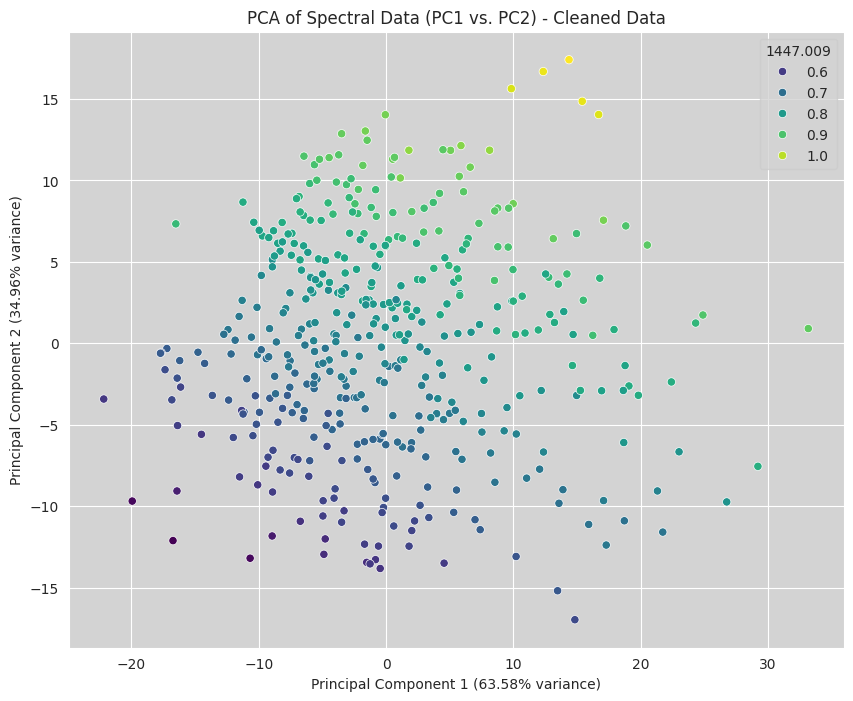

In [22]:
pca_cleaned = PCA(n_components=None)
pca_cleaned.fit(X_scaled_cleaned)

principal_components_cleaned = pca_cleaned.transform(X_scaled_cleaned)
pc_cols_cleaned = [f'PC{i+1}' for i in range(principal_components_cleaned.shape[1])]
principal_components_df_cleaned = pd.DataFrame(data=principal_components_cleaned,
                                       columns=pc_cols_cleaned,
                                       index=X_scaled_cleaned.index)

explained_variance_ratio_cleaned = pca_cleaned.explained_variance_ratio_

#Add the '1447.009' column from the cleaned original DataFrame to principal_components_df_cleaned
principal_components_df_cleaned['1447.009'] = df_no_pca_outliers['1447.009']

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=principal_components_df_cleaned, palette='viridis', hue='1447.009')
plt.title('PCA of Spectral Data (PC1 vs. PC2) - Cleaned Data')
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio_cleaned[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio_cleaned[1]*100:.2f}% variance)')
plt.grid(True)
plt.show()

### Product Ranking by Mean Spectral Value at Target Peak

This cell calculates the mean spectral signature for each product, isolates the absorbance values at the 1447.009nm target peak, and generates a bar chart to rank the products while visually distinguishing between 'Check' and 'Experimental' products.

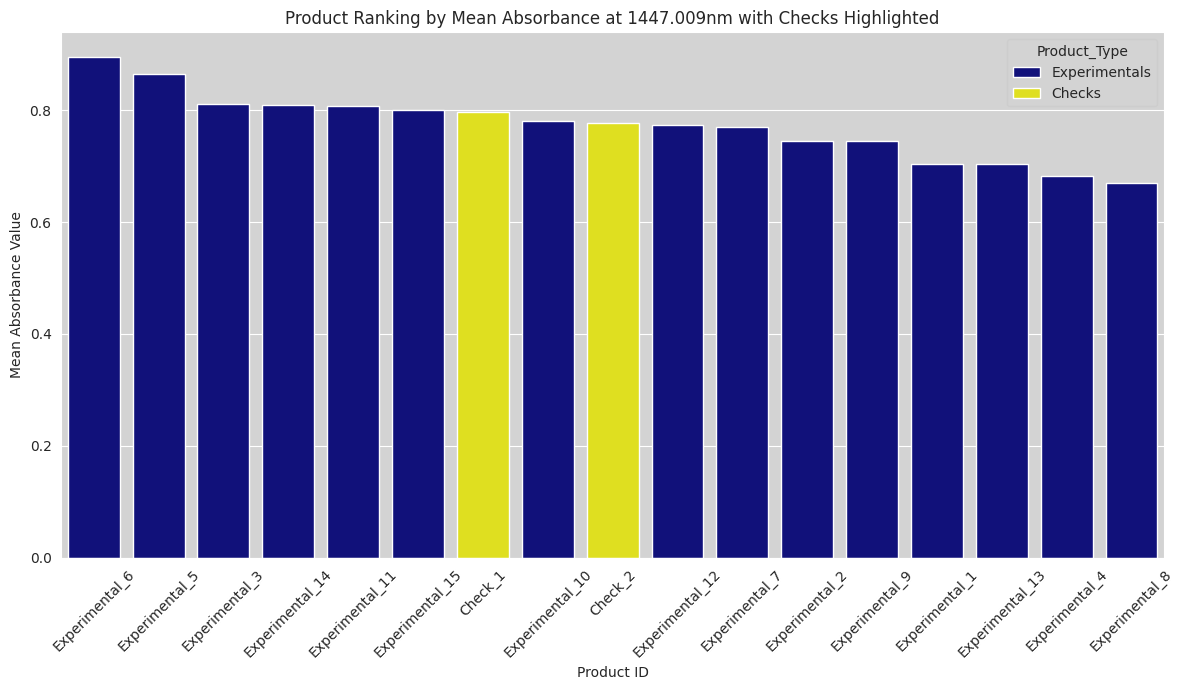

In [23]:
#Consolidate mean spectral signature calculations
mean_signatures_all = df_no_pca_outliers.groupby('Product ID')[spectral_cols_cleaned].mean()

#Reconstruct the DataFrame with wavelengths as index for the sorting operation
mean_signatures_for_sorting_purpose = mean_signatures_all.T
mean_signatures_for_sorting_purpose.index = mean_signatures_for_sorting_purpose.index.map(float)
mean_signatures_for_sorting_purpose = mean_signatures_for_sorting_purpose.sort_index()

#Identify the spectral band closest to 1450nm
closest_1450nm_band_float = 1447.009 #Directly use the specified band

#Calculate the mean spectral value for each product at the closest band
mean_values_for_sorting = mean_signatures_for_sorting_purpose.loc[closest_1450nm_band_float].sort_values(ascending=False)

ranked_products_cpi = mean_values_for_sorting.reset_index()
ranked_products_cpi.columns = ['Product ID', 'Mean_1447.009nm_Value']

#Define the specific product names for 'Checks'
check_product_names = ['Check_1', 'Check_2']

#Create a temporary 'Product_Type' column for visualization
ranked_products_cpi['Product_Type'] = ranked_products_cpi['Product ID'].apply(
    lambda x: 'Checks' if x in check_product_names else 'Experimentals'
)

plt.figure(figsize=(12, 7))
#Define a custom color palette
color_map = {'Checks': 'yellow', 'Experimentals': 'darkblue'}

sns.barplot(
    x='Product ID',
    y='Mean_1447.009nm_Value',
    hue='Product_Type',
    data=ranked_products_cpi,
    palette=color_map,
    dodge=False,
    legend='full'
)

plt.title('Product Ranking by Mean Absorbance at 1447.009nm with Checks Highlighted')
plt.xlabel('Product ID')
plt.ylabel('Mean Absorbance Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Drop the temporary column
ranks_cpi = ranked_products_cpi.drop(columns=['Product_Type'])

### Heatmap of Mean Spectral Bands

This cell calculates the mean spectral signature for each product and generates a heatmap to visualize the average absorbance across all spectral bands.

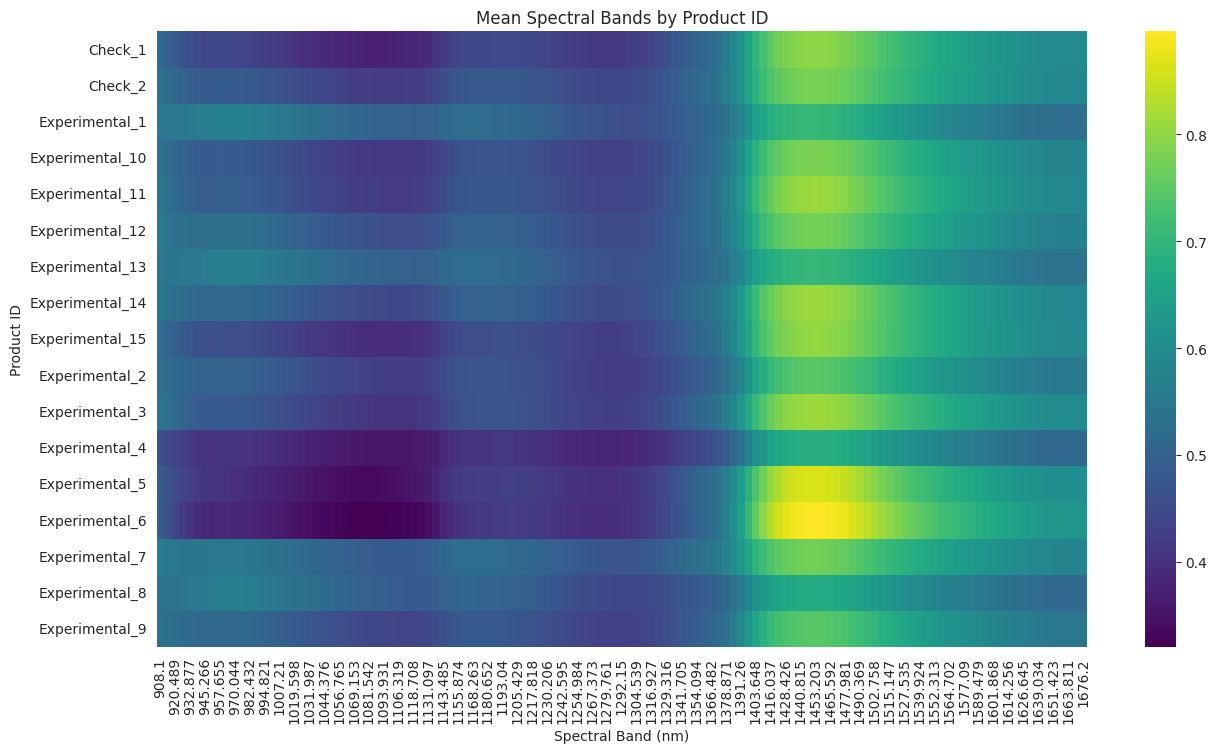

In [24]:
#Calculate the mean spectral signature for all Product Names
#spectral_cols_cleaned is already defined and contains the column names for spectral bands
mean_signatures_all = df_no_pca_outliers.groupby('Product ID')[spectral_cols_cleaned].mean()

plt.figure(figsize=(15, 8))
sns.heatmap(mean_signatures_all, cmap='viridis')
plt.title('Mean Spectral Bands by Product ID')
plt.xlabel('Spectral Band (nm)')
plt.ylabel('Product ID')
plt.show()

### Focused Heatmap of the Target Region (1403.648-1601.868nm)

This cell calculates the mean spectral signature for each product, filters the data to a specific target region (1403.648nm - 1601.868nm), and generates a focused heatmap to visualize the average absorbance exclusively within this spectral range.

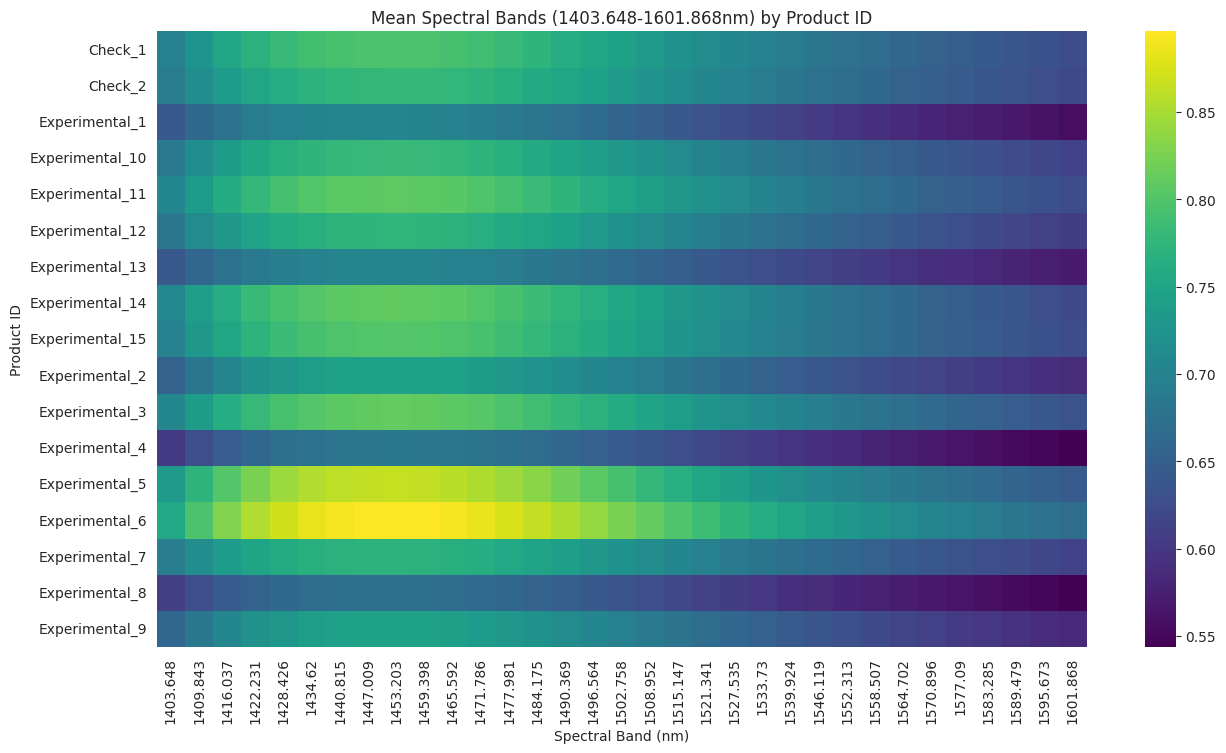

In [25]:
#Calculate the mean spectral signature for all Product IDs
#spectral_cols_cleaned is already defined and contains the column names for spectral bands
mean_signatures_all = df_no_pca_outliers.groupby('Product ID')[spectral_cols_cleaned].mean()

#Filter spectral columns to the 1403.648nm - 1601.868nm range
spectral_bands_custom_range = [col for col in spectral_cols_cleaned if 1403.648 <= float(col) <= 1601.868]
mean_signatures_custom_filtered = mean_signatures_all[spectral_bands_custom_range]

plt.figure(figsize=(15, 8))
sns.heatmap(mean_signatures_custom_filtered, cmap='viridis')
plt.title('Mean Spectral Bands (1403.648-1601.868nm) by Product ID')
plt.xlabel('Spectral Band (nm)')
plt.ylabel('Product ID')
plt.show()

### Interactive Mean Spectral Signatures (Sorted by Target Peak)

This cell transposes and sorts the mean spectral signatures based on their absorbance at the target peak (~1450nm) to generate an interactive line plot using Plotly, allowing for detailed comparison of product spectral profiles.

In [26]:
#Reconstruct the DataFrame with wavelengths as index for the sorting operation.
mean_signatures_for_sorting_purpose = mean_signatures_all.T
mean_signatures_for_sorting_purpose.index = mean_signatures_for_sorting_purpose.index.map(float)
mean_signatures_for_sorting_purpose = mean_signatures_for_sorting_purpose.sort_index()

#Prepare the transposed version for Plotly (with Wavelength as a column)
mean_signatures_all_transposed = mean_signatures_for_sorting_purpose.copy()
mean_signatures_all_transposed.index.name = 'Wavelength (nm)'
mean_signatures_all_transposed = mean_signatures_all_transposed.reset_index()

#Identify the spectral band closest to 1450nm
wavelengths_numeric = np.array([float(col) for col in spectral_cols_cleaned])
closest_1450nm_band_float = wavelengths_numeric[np.argmin(np.abs(wavelengths_numeric - 1450))]
closest_1450nm_band_str = str(closest_1450nm_band_float)

#Calculate the mean spectral value for each product at the closest band
mean_values_for_sorting = mean_signatures_for_sorting_purpose.loc[closest_1450nm_band_float].sort_values(ascending=False)

#Reorder the columns of the transposed DataFrame based on these mean values
sorted_product_names = mean_values_for_sorting.index.tolist()
reordered_columns_for_plot = ['Wavelength (nm)'] + sorted_product_names
mean_signatures_all_transposed_sorted = mean_signatures_all_transposed[reordered_columns_for_plot]

#Create the interactive plot
fig_interactive = px.line(
    mean_signatures_all_transposed_sorted,
    x='Wavelength (nm)',
    y=sorted_product_names,
    title=f'Interactive Mean Spectral Signatures (Key Ranked by Average Intensity at {closest_1450nm_band_str}nm, the target peak)',
    labels={
        'value': 'Mean Absorbance Value',
        'variable': 'Product ID'
    },
    color_discrete_sequence=px.colors.sequential.Viridis #Use viridis color palette for sorting
)

fig_interactive.show()

### Mean Spectral Signatures for Commercial Checks

This cell isolates the spectral data for the commercial "check" products, calculates their mean spectral signatures, and generates an interactive line plot to visually compare their baseline absorbance profiles across all measured wavelengths.

In [27]:
#Define the Product IDS for which to show spectral signatures
products_to_plot = ['Check_1', 'Check_2']

#Filter the df_no_pca_outliers for these products
products_spectral_data = df_no_pca_outliers[df_no_pca_outliers['Product ID'].isin(products_to_plot)]

#Calculate the mean spectral signature for each product
#spectral_cols_cleaned is already defined and contains the column names for spectral bands
mean_signatures = products_spectral_data.groupby('Product ID')[spectral_cols_cleaned].mean()

#Transpose the DataFrame for plotting (wavelengths on x-axis, absorbance on y-axis)
mean_signatures_transposed = mean_signatures.T
mean_signatures_transposed.index = mean_signatures_transposed.index.map(float)
mean_signatures_transposed = mean_signatures_transposed.sort_index()

#Prepare DataFrame for Plotly Express (wavelengths as a column)
mean_signatures_transposed = mean_signatures_transposed.reset_index()
mean_signatures_transposed = mean_signatures_transposed.rename(columns={'index': 'Wavelength (nm)'})

#Create the interactive Plotly line plot
fig_plotly = px.line(
    mean_signatures_transposed,
    x='Wavelength (nm)',
    y=products_to_plot,
    title='Interactive Mean Spectral Signatures for Commercial Checks',
    labels={
        'value': 'Mean Absorbance Value',
        'variable': 'Product ID'
    },
    color_discrete_sequence=['yellow', 'darkblue'] #Set yellow for Check_1 and darkblue for Check_2
)

fig_plotly.show()

### Product Performance Index (PPI) Calculation and Display

This cell calculates the 'Product Performance Index' (PPI) based on the mean spectral values at 1447.009nm. It compares each product's value against a threshold determined by the 'check' products ('Check_1' and 'Check_2'), assigning '1' if above the threshold and '0' otherwise. The results are displayed in a 1-indexed table.

In [28]:
#Convert the mean_values_for_sorting Series to a DataFrame
ranked_products_ppi = mean_values_for_sorting.reset_index()
ranked_products_ppi.columns = ['Product ID', 'Mean_1447.009nm_Value']

#Define the check Product IDs and their values
check_product_names = ['Check_1', 'Check_2']
check1_value = ranked_products_ppi[ranked_products_ppi['Product ID'] == 'Check_1']['Mean_1447.009nm_Value'].iloc[0]
check2_value = ranked_products_ppi[ranked_products_ppi['Product ID'] == 'Check_2']['Mean_1447.009nm_Value'].iloc[0]

#The threshold for PPI=1 is above the HIGHER of the two check values
ppi_threshold = max(check1_value, check2_value)

#Create the 'PPI' column
ranked_products_ppi['PPI'] = ranked_products_ppi['Mean_1447.009nm_Value'].apply(lambda x: 1 if x > ppi_threshold else 0)

#Adjust the index to start from 1 for better readability
ranked_products_ppi = ranked_products_ppi.reset_index(drop=True).reset_index()
ranked_products_ppi['index'] = ranked_products_ppi['index'] + 1
ranked_products_ppi = ranked_products_ppi.set_index('index')

#Reset the index to make the current index a column, then rename it to 'Rank'
ranked_products_ppi_display = ranked_products_ppi.reset_index()
ranked_products_ppi_display = ranked_products_ppi_display.rename(columns={'index': 'Rank'})

#Set 'Rank' as the new index for display purposes, but don't modify the original `ranked_products_ppi` to avoid affecting subsequent steps that might rely on its current structure.
ranked_products_ppi_display = ranked_products_ppi_display.set_index('Rank')

print("Product Performance Index:")
display(ranked_products_ppi_display)


Product Performance Index:


,Product ID,Mean_1447.009nm_Value,PPI
Rank,,,
1,Experimental_6,0.894715,1
2,Experimental_5,0.864225,1
3,Experimental_3,0.810564,1
4,Experimental_14,0.809340,1
5,Experimental_11,0.807896,1
6,Experimental_15,0.800724,1
7,Check_1,0.796394,0
8,Experimental_10,0.780441,0
9,Check_2,0.777245,0


### Save Product Performance Index (PPI) Table to CSV

This cell saves the calculated and formatted Product Performance Index (PPI) table to a CSV file in your Google Drive for external use or record-keeping.

In [29]:
#Define the path to save the CSV file in Google Drive
output_csv_path = '/content/gdrive/MyDrive/processed_data.csv'

#Save the DataFrame to CSV, without writing the DataFrame index as a column
ranked_products_ppi_display.to_csv(output_csv_path, index=False)

print(f"Product Performance Index table saved successfully to: {output_csv_path}")

Product Performance Index table saved successfully to: /content/gdrive/MyDrive/processed_data.csv


### Workflow Summary

This workflow processes spectral data through a series of steps designed for exploratory data analysis, dimensionality reduction, outlier detection, and product ranking. The key stages are as follows:

1.  **Data Loading & Initial Inspection**: Spectral data is loaded from a CSV file into a pandas DataFrame, followed by an initial quality check to understand its structure and content.
2.  **Spectral Data Preprocessing**: Non-spectral columns are separated, and the spectral data is standardized using `StandardScaler` to prepare it for dimensionality reduction.
3.  **Principal Component Analysis (PCA)**: PCA is applied to the standardized spectral data to reduce its dimensionality. Scree plots are generated to determine the optimal number of components, and an initial scatter plot visualizes the first two principal components.
4.  **Outlier Detection**: The Isolation Forest algorithm is used on the first two principal components to identify and visualize outliers, ensuring subsequent analyses are based on robust data.
5.  **Data Cleaning & Re-evaluation**: Identified outliers are removed from the dataset, and PCA is re-applied to the cleaned data for refined visualization.
6.  **Product Performance Analysis**: Products are ranked based on their mean spectral values within a target region (1447.009nm). This includes generating bar plots, heatmaps of spectral bands, and interactive plots for detailed comparison.
7.  **Product Performance Index (PPI) Calculation**: A Product Performance Index is calculated by comparing product spectral values against defined thresholds from commercial 'check' products.
8.  **Results Export**: The final PPI table is saved to a CSV file for external use.